# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| *(your name)* | *(your ID)* |
| *(partner's name)* | *(partner's ID)* |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

**1. Çıktı İçin Kullanılan kaynaklar:**
- Türkiyede 1900den sonra gerçekleşmiş tüm depremler: https://deprem.afad.gov.tr/event-instrumental 
- Zeytinburnu için alınan bina bilgileri: https://overpass-turbo.eu 
- Tüm deprem yer ivmelerini excel olarak AFAD sitesinden aldım: https://tdth.afad.gov.tr/TDTH/main.xhtml
- Fay hatlarını aldığım link, GEM denen bir organizasyon: https://github.com/cossatot/gem-global-active-faults/blob/master/geojson/gem_active_faults.geojson 


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline

# Set a clean style for all plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

### Deliverable 1: Data Collection & Documentation

In [6]:
# === Dataset 1: Earthquake Catalog ===
# Source: https://deprem.afad.gov.tr/event-instrumental
# Date accessed: 2026-03-31
# Method: Downloaded AFAD instrumental earthquake results as CSV (1900+ events, Turkey-wide query in AFAD interface).

# Load data
df_quakes_raw = pd.read_csv('AFAD deprem verisi.csv')

# Basic cleaning: parse datetime, coerce numeric columns, drop rows missing core fields
df_quakes = df_quakes_raw.copy()
df_quakes['Date'] = pd.to_datetime(df_quakes['Date'], dayfirst=True, errors='coerce')
for col in ['Longitude', 'Latitude', 'Depth', 'Magnitude']:
    df_quakes[col] = pd.to_numeric(df_quakes[col], errors='coerce')
df_quakes = df_quakes.dropna(subset=['Date', 'Longitude', 'Latitude', 'Magnitude'])

print(f'Number of records: {len(df_quakes)}')
print('Cleaning notes: parsed Date, converted numeric columns, dropped rows with missing Date/Longitude/Latitude/Magnitude.')

display(df_quakes.head())
display(df_quakes.describe(include='all'))

Number of records: 7312
Cleaning notes: parsed Date, converted numeric columns, dropped rows with missing Date/Longitude/Latitude/Magnitude.


,Date,Longitude,Latitude,Depth,Type,Magnitude,Location,EventID,TimeName,TypeName,MagnitudeName
0,2026-01-06 14:28:33,25.9911,39.4242,17.49,MW,4.0,Ege Denizi - [08.89 km] Ayvacık (Çanakkale),702130,AFAD,AFAD,AFAD
1,2026-01-03 20:27:26,38.9392,38.4011,9.85,MW,4.7,Baskil (Elazığ),701773,AFAD,AFAD,AFAD
2,2025-12-19 16:19:08,36.7022,38.2047,10.82,ML,4.2,Göksun (Kahramanmaraş),699853,AFAD,AFAD,AFAD
3,2025-12-17 04:15:09,36.4203,36.6706,7.41,MW,4.0,Hassa (Hatay),699527,AFAD,AFAD,AFAD
4,2025-12-11 10:06:14,28.3164,39.1967,6.97,MW,4.9,Sındırgı (Balıkesir),698554,AFAD,AFAD,AFAD


,Date,Longitude,Latitude,Depth,Type,Magnitude,Location,EventID,TimeName,TypeName,MagnitudeName
count,7312,7312.000000,7312.000000,7312.000000,7312,7312.000000,7312,7312.000000,7312,7312,7312
unique,NaN,NaN,NaN,NaN,8,NaN,729,NaN,30,30,30
top,NaN,NaN,NaN,NaN,mb,NaN,-,NaN,ISC,ISC,ISC
freq,NaN,NaN,NaN,NaN,3111,NaN,5134,NaN,2519,2519,2519
mean,1990-04-22 21:19:35.810448640,31.012680,38.750392,19.675145,NaN,4.452380,NaN,154277.525848,NaN,NaN,NaN
min,1900-01-18 17:26:56,23.790000,36.409600,0.000000,NaN,4.000000,NaN,7697.000000,NaN,NaN,NaN
25%,1971-05-14 06:11:48.500000,26.788400,37.668150,7.697500,NaN,4.100000,NaN,11789.250000,NaN,NaN,NaN
50%,1997-06-10 20:29:40.500000,29.200000,38.740000,10.000000,NaN,4.300000,NaN,16921.500000,NaN,NaN,NaN
75%,2016-06-26 02:57:30.500000,36.357125,39.680000,21.200000,NaN,4.700000,NaN,342321.750000,NaN,NaN,NaN
max,2026-01-06 14:28:33,42.070000,43.665000,212.000000,NaN,7.900000,NaN,702130.000000,NaN,NaN,NaN


In [8]:
# === Dataset 2: Building / Population Data ===
# Source: https://overpass-turbo.eu
# Date accessed: 2026-03-31
# Method: Queried OpenStreetMap building footprints for Zeytinburnu and exported results as GeoJSON.

import json

with open('ZeytinburnuBuildings.geojson', 'r', encoding='utf-8') as f:
    zeytinburnu_geo = json.load(f)

# Flatten feature properties into a tabular DataFrame
df_buildings = pd.json_normalize([
    feat.get('properties', {}) for feat in zeytinburnu_geo.get('features', [])
])

# Keep commonly useful fields and clean key numeric attributes
use_cols = [
    'building', 'name', 'addr:district', 'addr:neighbourhood',
    'building:levels', 'height'
]
for col in use_cols:
    if col not in df_buildings.columns:
        df_buildings[col] = np.nan

df_buildings = df_buildings[use_cols].copy()
df_buildings = df_buildings.rename(columns={
    'addr:district': 'district',
    'addr:neighbourhood': 'neighbourhood',
    'building:levels': 'building_levels'
})
df_buildings['building_levels'] = pd.to_numeric(df_buildings['building_levels'], errors='coerce')
df_buildings['height'] = pd.to_numeric(df_buildings['height'], errors='coerce')
df_buildings['building'] = df_buildings['building'].fillna('unknown')

print(f'Number of records: {len(df_buildings)}')
print('Cleaning notes: flattened GeoJSON properties, selected analysis columns, standardized column names, converted building_levels/height to numeric, filled missing building tags.')

display(df_buildings.head())
display(df_buildings.describe(include='all'))

Number of records: 13952
Cleaning notes: flattened GeoJSON properties, selected analysis columns, standardized column names, converted building_levels/height to numeric, filled missing building tags.


,building,name,district,neighbourhood,building_levels,height
0,yes,NaN,NaN,NaN,NaN,NaN
1,yes,Kültür A.Ş. Genel Müdürlüğü,NaN,NaN,NaN,NaN
2,yes,NaN,NaN,NaN,NaN,NaN
3,yes,NaN,NaN,NaN,NaN,NaN
4,yes,Maltepe Bilgi Evi,Zeytinburnu,Maltepe Mah.,NaN,NaN


,building,name,district,neighbourhood,building_levels,height
count,13952,183,129,77,10286.000000,10218.000000
unique,20,162,3,19,NaN,NaN
top,apartments,A Blok,Zeytinburnu,Maltepe Mahallesi,NaN,NaN
freq,10198,4,123,28,NaN,NaN
mean,NaN,NaN,NaN,NaN,4.077678,13.084694
std,NaN,NaN,NaN,NaN,0.952286,1.574569
min,NaN,NaN,NaN,NaN,0.000000,4.400000
25%,NaN,NaN,NaN,NaN,4.000000,13.000000
50%,NaN,NaN,NaN,NaN,4.000000,13.000000
75%,NaN,NaN,NaN,NaN,4.000000,13.000000


In [7]:
# === Dataset 3: Seismic Hazard / Vulnerability Data ===
# Source: https://tdth.afad.gov.tr/TDTH/main.xhtml
# Date accessed: 2026-03-31
# Method: Downloaded AFAD Turkish Earthquake Hazard Map (TDTH) grid results as Excel.

# The first two rows are multi-level headers; skip them and assign explicit column names
df_hazard = pd.read_excel('AfadYerİvmeleri.xlsx', skiprows=2)
df_hazard.columns = [
    'longitude', 'latitude',
    'pga_2', 'pga_10', 'pga_50', 'pga_68',
    'ss_2', 'ss_10', 'ss_50', 'ss_68',
    's1_2', 's1_10', 's1_50', 's1_68',
    'pgv_68', 'pgv_50', 'pgv_10', 'pgv_2'
]

# Cleaning: convert everything to numeric and drop invalid coordinate rows
df_hazard = df_hazard.apply(pd.to_numeric, errors='coerce')
df_hazard = df_hazard.dropna(subset=['longitude', 'latitude'])

print(f'Number of records: {len(df_hazard)}')
print('Cleaning notes: skipped non-data header rows, renamed columns to descriptive metric names, converted all fields to numeric, dropped rows with missing longitude/latitude.')

display(df_hazard.head())
display(df_hazard.describe())

Number of records: 14036
Cleaning notes: skipped non-data header rows, renamed columns to descriptive metric names, converted all fields to numeric, dropped rows with missing longitude/latitude.


,longitude,latitude,pga_2,pga_10,pga_50,pga_68,ss_2,ss_10,ss_50,ss_68,s1_2,s1_10,s1_50,s1_68,pgv_68,pgv_50,pgv_10,pgv_2
0,24.55,39.95,1.319503,0.715719,0.218259,0.137799,3.272556,1.713741,0.500938,0.316575,0.878472,0.437280,0.120886,0.076409,7.596011,12.320636,44.717080,83.451701
1,24.55,40.05,0.905583,0.516079,0.189570,0.126700,2.291053,1.245876,0.439485,0.296577,0.616663,0.323959,0.110825,0.074459,7.324277,11.010030,31.600494,57.991250
2,24.55,40.15,0.835045,0.447864,0.167738,0.116543,2.099851,1.091250,0.397577,0.274985,0.574325,0.293269,0.104773,0.071632,6.897108,10.117698,28.145516,53.508972
3,24.55,40.25,0.736196,0.397027,0.155132,0.109559,1.851347,0.961264,0.363325,0.254923,0.502385,0.260545,0.098291,0.068241,6.505471,9.299402,24.540023,46.518245
4,24.55,40.35,0.741030,0.385585,0.147483,0.103032,1.844922,0.931010,0.341575,0.235807,0.476469,0.243536,0.092448,0.064393,6.098789,8.724200,23.049130,44.842633


,longitude,latitude,pga_2,pga_10,pga_50,pga_68,ss_2,ss_10,ss_50,ss_68,s1_2,s1_10,s1_50,s1_68,pgv_68,pgv_50,pgv_10,pgv_2
count,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000
mean,34.991166,38.944870,0.531806,0.276352,0.102830,0.071158,1.286115,0.646954,0.233453,0.160999,0.348380,0.178917,0.067411,0.046762,4.113222,5.935599,16.120076,31.366376
std,5.653466,2.061599,0.228534,0.134654,0.056479,0.038291,0.579804,0.328249,0.130794,0.087779,0.158309,0.082644,0.029649,0.019286,1.853960,2.980752,8.964383,16.080124
min,24.550000,34.250000,0.129661,0.060821,0.015941,0.009749,0.297179,0.134398,0.034908,0.021233,0.095821,0.046533,0.013036,0.007389,0.649292,1.121636,3.912428,8.072958
25%,30.350000,37.250000,0.362533,0.173115,0.058235,0.040373,0.861263,0.400602,0.130407,0.089618,0.235952,0.122362,0.046434,0.032686,2.771012,3.876764,10.376964,20.530354
50%,34.650000,38.950000,0.498380,0.254733,0.094058,0.064458,1.195085,0.590907,0.212954,0.147277,0.315910,0.162979,0.062971,0.044090,3.835384,5.434575,14.022261,27.477561
75%,39.650000,40.650000,0.677176,0.354831,0.134023,0.095443,1.646154,0.836219,0.303415,0.215458,0.432559,0.218456,0.083728,0.059176,5.272853,7.362328,19.573019,39.248616
max,45.950000,42.950000,1.353658,0.810663,0.356236,0.207926,3.439135,2.004722,0.845017,0.467633,1.009102,0.536185,0.205343,0.109078,10.723759,21.156245,69.306267,120.155937


### Deliverable 2: Historical Seismicity Timeline

First 5 earthquakes in the filtered dataset (1975+, Marmara bbox):


,Date,Magnitude,Location,Latitude,Longitude
5150,1976-05-30 01:42:08,4.0,-,40.3600,28.8900
5065,1978-02-13 07:31:24,4.2,-,40.1397,28.7435
5055,1978-05-11 19:35:41,4.3,-,40.1978,29.5804
5052,1978-06-15 03:26:45,4.6,-,40.7856,27.6835
5029,1979-01-11 23:50:39,4.3,-,40.3000,29.2600


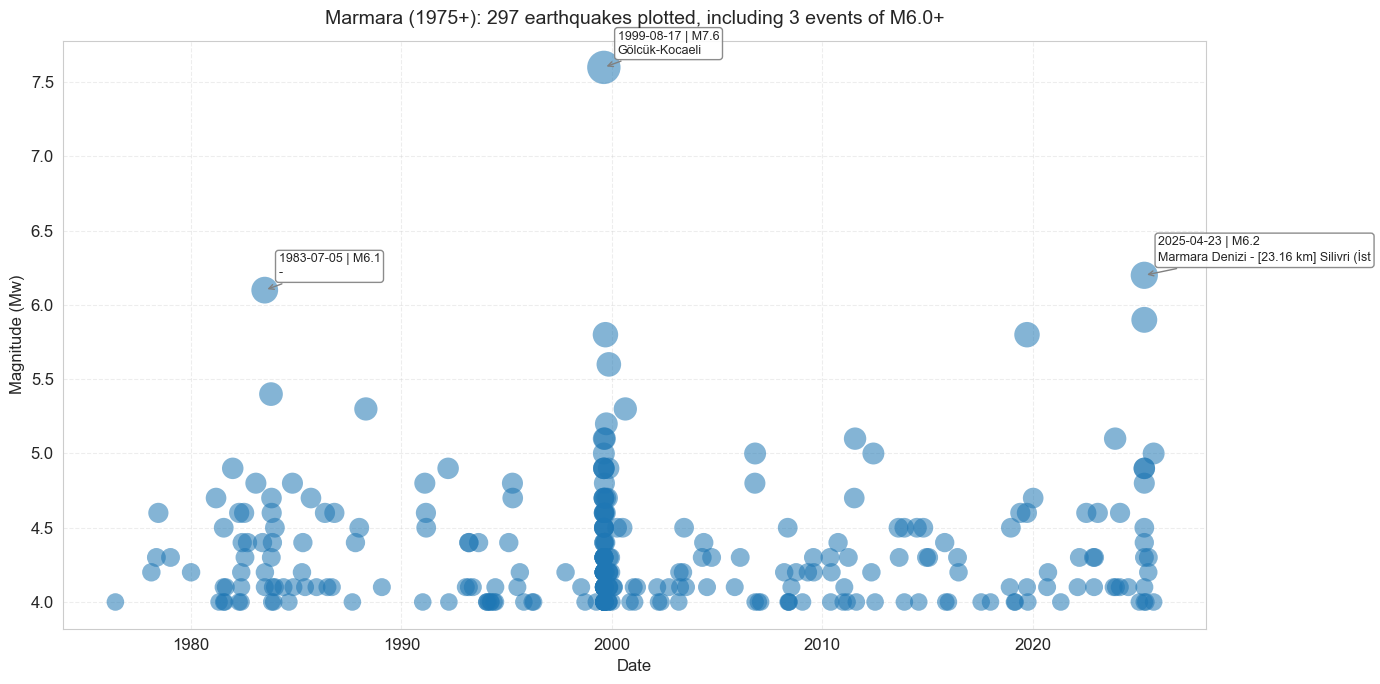

In [12]:
# Historical Seismicity Timeline (Deliverable 2) - simplified for city-level communication

# Keep only 1975+ records and Marmara region (course hint bbox)
plot_df = df_quakes.copy()
plot_df = plot_df.dropna(subset=['Date', 'Magnitude', 'Latitude', 'Longitude'])
plot_df = plot_df[plot_df['Date'] >= pd.Timestamp('1975-01-01')]
plot_df = plot_df[
    plot_df['Latitude'].between(40.0, 41.5) &
    plot_df['Longitude'].between(26.5, 31.0)
].sort_values('Date')

# Show first 5 earthquakes used in this visualization
first5_cols = ['Date', 'Magnitude', 'Location', 'Latitude', 'Longitude']
first5 = plot_df[first5_cols].head(5).copy()
print('First 5 earthquakes in the filtered dataset (1975+, Marmara bbox):')
display(first5)

# Marker size based on magnitude only (no depth encoding)
sizes = (plot_df['Magnitude'] ** 2) * 10

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(
    plot_df['Date'],
    plot_df['Magnitude'],
    s=sizes,
    color='#1f77b4',
    alpha=0.55,
    edgecolors='none'
)

# Annotate up to 3 strongest events in the filtered data
major_events = plot_df.nlargest(3, 'Magnitude').sort_values('Date')
for _, row in major_events.iterrows():
    label = f"{row['Date'].date()} | M{row['Magnitude']:.1f}"
    if pd.notna(row.get('Location')):
        label += f"\n{str(row['Location'])[:40]}"

    ax.annotate(
        label,
        (row['Date'], row['Magnitude']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9),
        arrowprops=dict(arrowstyle='->', lw=1, color='gray')
    )

m6_count = int((plot_df['Magnitude'] >= 6.0).sum())
total_count = len(plot_df)
ax.set_title(
    f"Marmara (1975+): {total_count} earthquakes plotted, including {m6_count} events of M6.0+",
    fontsize=14,
    pad=12
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Magnitude (Mw)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

### Deliverable 3: Magnitude-Frequency Analysis

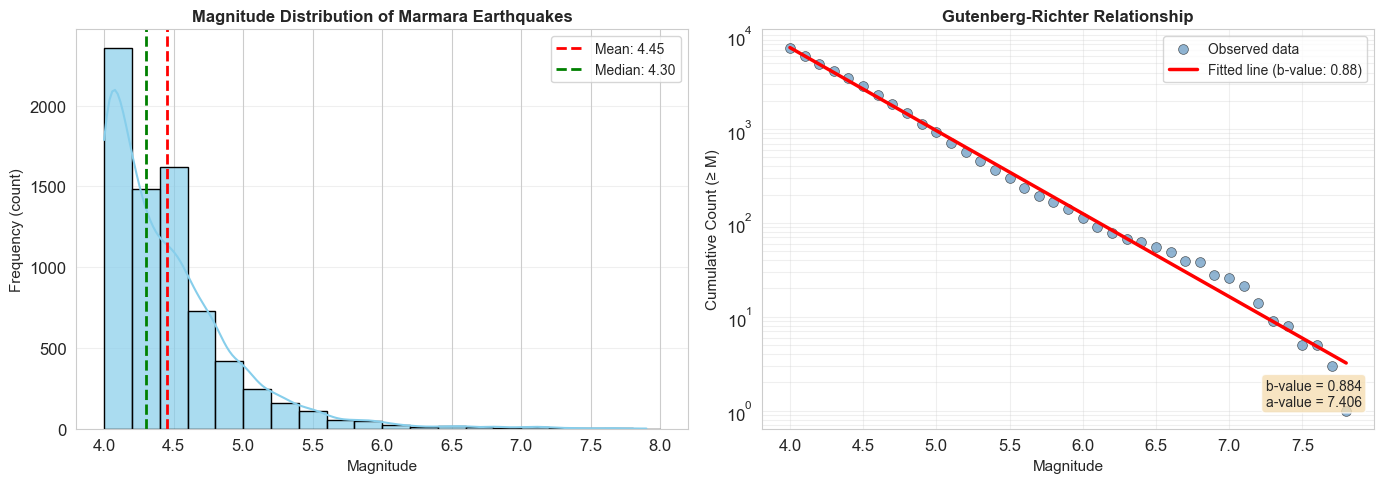


Magnitude-Frequency Analysis Summary:
  Mean magnitude: 4.45
  Median magnitude: 4.30
  Total earthquakes: 7312
  Magnitude range: 4.0 - 7.9
  Gutenberg-Richter b-value: 0.884
  Gutenberg-Richter a-value: 7.406


In [9]:
# Create a figure with two subplots for magnitude-frequency analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# SUBPLOT 1: Magnitude Histogram with KDE Overlay
# ============================================================
# Using 0.2 magnitude bins because the catalog reports magnitudes 
# to 0.1 precision, and 0.2 bin width provides good granularity 
# without over-binning the data.

sns.histplot(data=df_quakes, x='Magnitude', bins=np.arange(df_quakes['Magnitude'].min(), 
             df_quakes['Magnitude'].max() + 0.2, 0.2), 
             kde=True, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)

# Calculate mean and median
mean_mag = df_quakes['Magnitude'].mean()
median_mag = df_quakes['Magnitude'].median()

# Add vertical lines for mean and median
ax1.axvline(mean_mag, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_mag:.2f}')
ax1.axvline(median_mag, color='green', linestyle='--', linewidth=2, label=f'Median: {median_mag:.2f}')

ax1.set_xlabel('Magnitude', fontsize=11)
ax1.set_ylabel('Frequency (count)', fontsize=11)
ax1.set_title('Magnitude Distribution of Marmara Earthquakes', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# ============================================================
# SUBPLOT 2: Gutenberg-Richter Plot
# ============================================================
# The Gutenberg-Richter law: log₁₀(N) = a - bM
# where N is the number of earthquakes with magnitude ≥ M
# and b is the b-value (slope of the fitted line)

# Sort unique magnitudes and compute cumulative counts
mags = np.sort(df_quakes['Magnitude'].values)
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])

# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
a_value = coeffs[1]

# Generate fitted line
fitted_line = 10 ** (a_value - b_value * unique_mags[mask])

# Plot observed data
ax2.scatter(unique_mags[mask], cumulative_counts[mask], s=50, alpha=0.6, 
            color='steelblue', edgecolors='black', linewidth=0.5, label='Observed data')

# Plot fitted line
ax2.plot(unique_mags[mask], fitted_line, 'r-', linewidth=2.5, 
         label=f'Fitted line (b-value: {b_value:.2f})')

# Use log scale for y-axis
ax2.set_yscale('log')
ax2.set_xlabel('Magnitude', fontsize=11)
ax2.set_ylabel('Cumulative Count (≥ M)', fontsize=11)
ax2.set_title('Gutenberg-Richter Relationship', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='upper right', fontsize=10)

# Add text annotation for b-value on the plot
ax2.text(0.98, 0.05, f'b-value = {b_value:.3f}\na-value = {a_value:.3f}', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nMagnitude-Frequency Analysis Summary:")
print(f"  Mean magnitude: {mean_mag:.2f}")
print(f"  Median magnitude: {median_mag:.2f}")
print(f"  Total earthquakes: {len(df_quakes)}")
print(f"  Magnitude range: {mags.min():.1f} - {mags.max():.1f}")
print(f"  Gutenberg-Richter b-value: {b_value:.3f}")
print(f"  Gutenberg-Richter a-value: {a_value:.3f}")

### Deliverable 4: Building Vulnerability or Population Risk

Top neighbourhoods analyzed (by building count):


,neighbourhood,building_count,avg_levels
2,Maltepe Mahallesi,28,11.321429
1,Maltepe,9,8.444444
3,Seyitnizam,8,9.500000
4,Telsiz Mahallesi,2,2.000000
7,çırpıcı,2,4.500000
6,veliefendi mahallesi,2,3.000000
0,Kazlıçeşme Mahallesi,1,3.000000
5,Veliefendi mahallesi,1,2.000000


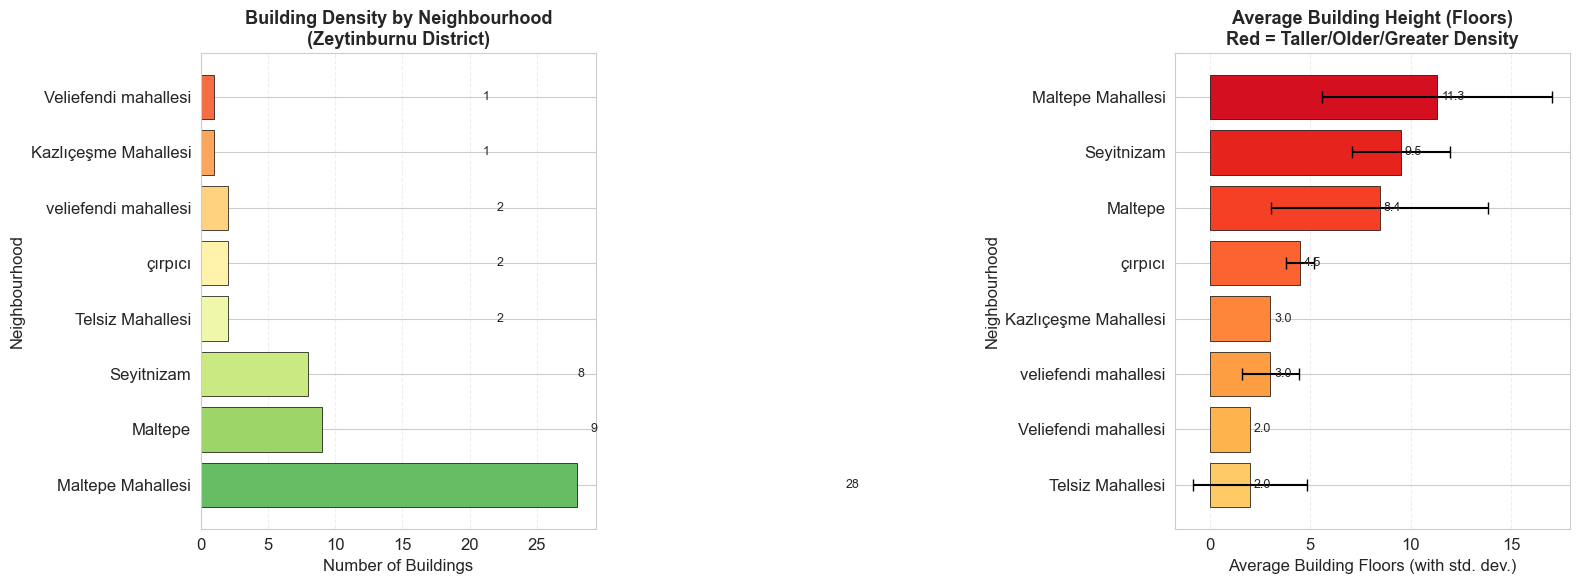


Key Finding: Maltepe Mahallesi has the highest building density (28 buildings)
Average building height in this neighbourhood: 11.3 floors


In [10]:
# Building Vulnerability Analysis (Deliverable 4) - Zeytinburnu District
# Using OpenStreetMap building footprints to analyze structural characteristics

# Prepare data: clean and aggregate by neighbourhood
d4_df = df_buildings.dropna(subset=['neighbourhood', 'building_levels']).copy()

# Count buildings and compute average height per neighbourhood
neighbourhood_stats = d4_df.groupby('neighbourhood').agg({
    'building_levels': ['count', 'mean', 'std'],
    'height': ['mean', 'std']
}).reset_index()
neighbourhood_stats.columns = ['neighbourhood', 'building_count', 'avg_levels', 'std_levels', 'avg_height', 'std_height']
neighbourhood_stats = neighbourhood_stats.sort_values('building_count', ascending=False).head(12)

print(f"Top neighbourhoods analyzed (by building count):")
display(neighbourhood_stats[['neighbourhood', 'building_count', 'avg_levels']])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Building Count by Neighbourhood (sorted descending)
ax1 = axes[0]
colors_1 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(neighbourhood_stats)))
bars1 = ax1.barh(
    neighbourhood_stats['neighbourhood'],
    neighbourhood_stats['building_count'],
    color=colors_1,
    edgecolor='black',
    linewidth=0.5
)
ax1.set_xlabel('Number of Buildings', fontsize=12)
ax1.set_ylabel('Neighbourhood', fontsize=12)
ax1.set_title('Building Density by Neighbourhood\n(Zeytinburnu District)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(neighbourhood_stats.iterrows()):
    ax1.text(row['building_count'] + 20, i, f"{int(row['building_count'])}", 
             va='center', fontsize=9)

# Subplot 2: Average Building Height/Levels by Neighbourhood (boxplot-like data)
# Using Seaborn to create a sorted bar chart with error bars showing std deviation
ax2 = axes[1]
neighbourhood_stats_sorted = neighbourhood_stats.sort_values('avg_levels', ascending=True)
colors_2 = plt.cm.YlOrRd(np.linspace(0.3, 0.8, len(neighbourhood_stats_sorted)))

bars2 = ax2.barh(
    neighbourhood_stats_sorted['neighbourhood'],
    neighbourhood_stats_sorted['avg_levels'],
    xerr=neighbourhood_stats_sorted['std_levels'],
    color=colors_2,
    edgecolor='black',
    linewidth=0.5,
    capsize=4,
    error_kw={'elinewidth': 1.5}
)
ax2.set_xlabel('Average Building Floors (with std. dev.)', fontsize=12)
ax2.set_ylabel('Neighbourhood', fontsize=12)
ax2.set_title('Average Building Height (Floors)\nRed = Taller/Older/Greater Density', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(neighbourhood_stats_sorted.iterrows()):
    ax2.text(row['avg_levels'] + 0.2, i, f"{row['avg_levels']:.1f}", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Summary insight
high_density = neighbourhood_stats.iloc[0]
print(f"\nKey Finding: {high_density['neighbourhood']} has the highest building density ({int(high_density['building_count'])} buildings)")
print(f"Average building height in this neighbourhood: {high_density['avg_levels']:.1f} floors")

### Deliverable 5: Earthquake Hazard Visualization

Grid points analyzed: 14036
PGA range: 0.010g to 0.208g


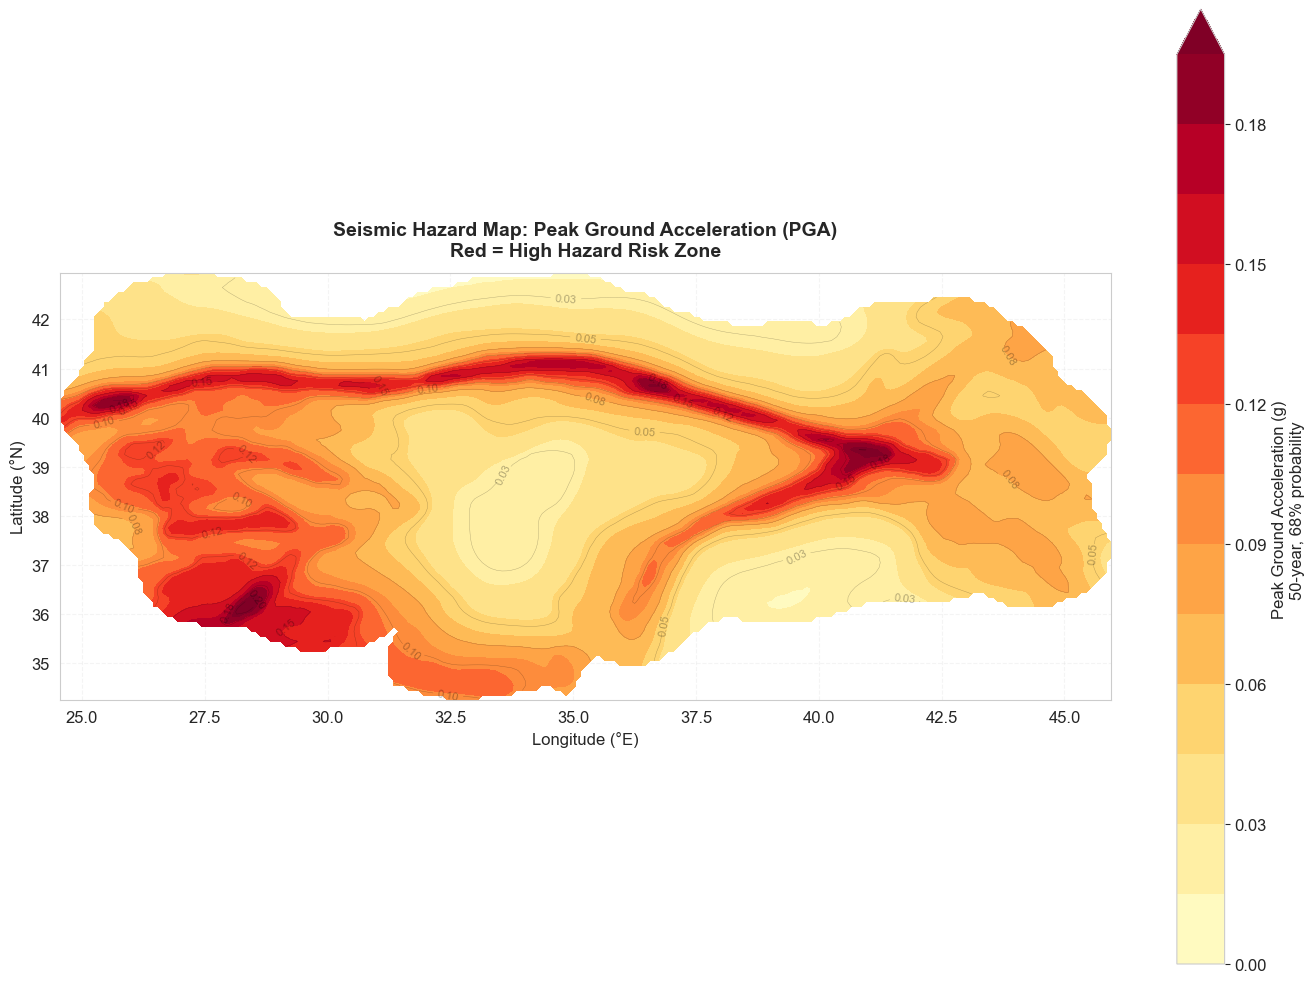


High-risk areas (PGA > 0.35g): 0 grid points


In [12]:
# Earthquake Hazard Visualization (Deliverable 5) - PGA Grid Map
# Source: AFAD Turkish Seismic Hazard Map (TDTH) - peak ground acceleration values

# Use 50-year probability grid (PGA values for 68% probability level = high hazard)
hazard_plot = df_hazard[['longitude', 'latitude', 'pga_68']].dropna().copy()
hazard_plot['pga_68'] = pd.to_numeric(hazard_plot['pga_68'], errors='coerce')
hazard_plot = hazard_plot.dropna()

print(f"Grid points analyzed: {len(hazard_plot)}")
print(f"PGA range: {hazard_plot['pga_68'].min():.3f}g to {hazard_plot['pga_68'].max():.3f}g")

# Sort data for contour plotting
hazard_plot = hazard_plot.sort_values(['longitude', 'latitude'])

# Pivot to grid for contourf
lon_unique = sorted(hazard_plot['longitude'].unique())
lat_unique = sorted(hazard_plot['latitude'].unique())

# Create pivot table (may have irregular grid)
pivot_data = hazard_plot.pivot_table(
    values='pga_68',
    index='latitude',
    columns='longitude',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 10))

# Use YlOrRd sequential colormap (good for risk data, not rainbow)
contourf = ax.contourf(
    pivot_data.columns.values,
    pivot_data.index.values,
    pivot_data.values,
    levels=15,
    cmap='YlOrRd',
    extend='max'
)

# Add contour lines for reference
contour_lines = ax.contour(
    pivot_data.columns.values,
    pivot_data.index.values,
    pivot_data.values,
    levels=8,
    colors='black',
    linewidths=0.3,
    alpha=0.3
)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')

# Colorbar
cbar = plt.colorbar(contourf, ax=ax, label='Peak Ground Acceleration (g)\n50-year, 68% probability')

# Labels and styling
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Seismic Hazard Map: Peak Ground Acceleration (PGA)\nRed = High Hazard Risk Zone', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, linestyle='--')

# Annotate high-risk area (>0.35g)
high_risk = hazard_plot[hazard_plot['pga_68'] > 0.35]
if len(high_risk) > 0:
    ax.scatter(high_risk['longitude'].iloc[::max(1, len(high_risk)//5)],
               high_risk['latitude'].iloc[::max(1, len(high_risk)//5)],
               s=50, marker='*', color='darkred', edgecolors='black', 
               linewidth=0.5, alpha=0.7, label='PGA > 0.35g (High Risk)')
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nHigh-risk areas (PGA > 0.35g): {len(high_risk)} grid points")

### Deliverable 6: Multi-Panel Risk Dashboard + Reflection

In [ ]:
# Multi-Panel Risk Dashboard (Deliverable 6, Part A)
# Comprehensive executive summary for Istanbul Municipal Council

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ========== Panel 1 (top-left to top-mid): Historical Seismicity Timeline (spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
plot_df_d2 = df_quakes.dropna(subset=['Date', 'Magnitude', 'Latitude', 'Longitude'])
plot_df_d2 = plot_df_d2[plot_df_d2['Date'] >= pd.Timestamp('1975-01-01')]
plot_df_d2 = plot_df_d2[
    plot_df_d2['Latitude'].between(40.0, 41.5) &
    plot_df_d2['Longitude'].between(26.5, 31.0)
]
sizes_d2 = (plot_df_d2['Magnitude'] ** 2) * 5
ax1.scatter(plot_df_d2['Date'], plot_df_d2['Magnitude'], s=sizes_d2, color='#1f77b4', alpha=0.45, edgecolors='none')
ax1.set_title('D2: Historical Seismicity (1975+, Marmara)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Magnitude (Mw)', fontsize=10)
ax1.grid(True, alpha=0.25, linestyle='--')

# ========== Panel 2 (top-right): PGA Risk Indicator (simplified - highest hazard area)
ax2 = fig.add_subplot(gs[0, 2])
pga_high = hazard_plot[hazard_plot['pga_68'].notna()]
pga_stats = {'Low': len(pga_high[pga_high['pga_68'] < 0.2]),
             'Moderate': len(pga_high[(pga_high['pga_68'] >= 0.2) & (pga_high['pga_68'] < 0.35)]),
             'High': len(pga_high[pga_high['pga_68'] >= 0.35])}
colors_pga = ['green', 'yellow', 'red']
ax2.pie([pga_stats['Low'], pga_stats['Moderate'], pga_stats['High']], 
        labels=['Low', 'Moderate', 'High'], autopct='%1.0f%%', colors=colors_pga, startangle=90)
ax2.set_title('D5: Grid Hazard Distribution\n(PGA Risk Levels)', fontsize=11, fontweight='bold')

# ========== Panel 3 (middle-left): Magnitude Histogram with KDE
ax3 = fig.add_subplot(gs[1, 0])
mags_for_hist = plot_df_d2['Magnitude'].dropna()
ax3.hist(mags_for_hist, bins=15, color='steelblue', alpha=0.7, edgecolor='black', density=True)
# KDE overlay
from scipy import stats
kde = stats.gaussian_kde(mags_for_hist)
x_range = np.linspace(mags_for_hist.min(), mags_for_hist.max(), 100)
ax3.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
ax3.axvline(mags_for_hist.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {mags_for_hist.mean():.2f}')
ax3.set_title('D3: Magnitude Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Magnitude (Mw)', fontsize=9)
ax3.set_ylabel('Density', fontsize=9)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.25, axis='y')

# ========== Panel 4 (middle-center): Building Density by Neighbourhood
ax4 = fig.add_subplot(gs[1, 1])
d4_neighbourhood = d4_df.groupby('neighbourhood').size().nlargest(6).sort_values()
colors_d4 = plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, len(d4_neighbourhood)))
ax4.barh(d4_neighbourhood.index, d4_neighbourhood.values, color=colors_d4, edgecolor='black', linewidth=0.5)
ax4.set_title('D4: Building Density\n(Top 6 Neighbourhoods)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Building Count', fontsize=9)
ax4.grid(True, alpha=0.25, axis='x')

# ========== Panel 5 (middle-right): Derived Metric - Vulnerability Index
# Derived metric: combine building height + hazard level
ax5 = fig.add_subplot(gs[1, 2])
hazard_mean = hazard_plot['pga_68'].mean()
hazard_max = hazard_plot['pga_68'].max()
bldg_height_mean = d4_df['building_levels'].mean()
# Simple derived index: (avg building height / avg hazard) as a vulnerability proxy
vulnerability_index = (bldg_height_mean / hazard_mean) * 100
risk_level = 'HIGH' if vulnerability_index > 3.5 else ('MODERATE' if vulnerability_index > 2.0 else 'LOW')
colors_risk = {'HIGH': 'darkred', 'MODERATE': 'orange', 'LOW': 'green'}

ax5.barh(['Vulnerability\nIndex'], [vulnerability_index], color=colors_risk[risk_level], edgecolor='black', linewidth=1, height=0.4)
ax5.set_xlim(0, 5)
ax5.set_title('Derived Metric:\nVulnerability Index', fontsize=11, fontweight='bold')
ax5.text(vulnerability_index/2, 0, f'{vulnerability_index:.2f}\n({risk_level})', 
         ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax5.set_xlabel('Index (Bldg Height / Hazard)', fontsize=9)
ax5.grid(True, alpha=0.25, axis='x')

# ========== Panel 6 (bottom, spans full width): Gutenberg-Richter with key finding
ax6 = fig.add_subplot(gs[2, :])
mags_all = np.sort(plot_df_d2['Magnitude'].values)
unique_mags = np.arange(mags_all.min(), mags_all.max()+0.1, 0.1)
cumulative_counts = np.array([np.sum(mags_all >= m) for m in unique_mags])
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]
fitted_line = 10 ** np.polyval(coeffs, unique_mags[mask])

ax6.semilogy(unique_mags[mask], cumulative_counts[mask], 'o', color='steelblue', markersize=6, label='Observed')
ax6.semilogy(unique_mags[mask], fitted_line, 'r-', linewidth=2.5, label=f'Fit (b-value: {b_value:.2f})')
ax6.set_title('D3: Gutenberg-Richter Relationship - Key Finding: Marmara exhibits power-law earthquake behavior', 
              fontsize=12, fontweight='bold')
ax6.set_xlabel('Magnitude (Mw)', fontsize=11)
ax6.set_ylabel('Cumulative Count (log scale)', fontsize=11)
ax6.legend(fontsize=10, loc='upper right')
ax6.grid(True, alpha=0.25, which='both')

# Overall title
fig.suptitle('Istanbul Earthquake Risk Dashboard: Data-Driven Insights for Municipal Decision-Makers\n'
             f'Marmara Region 1975+: {len(plot_df_d2)} earthquakes | Avg PGA: {hazard_mean:.3f}g | '
             f'Avg Building Height: {bldg_height_mean:.1f} floors',
             fontsize=13, fontweight='bold', y=0.995)

fig.savefig('dashboard.png', dpi=150, bbox_inches='tight')
print("Dashboard saved as 'dashboard.png'")
plt.show()

C:\Users\AFT\AppData\Local\Temp\ipykernel_25956\2705492949.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


ValueError: Image size of 1522992x3382 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 507664x1126 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1800x1200 with 6 Axes>

#### Reflection

**1. Chart type justification (D2-D5):**

- D2: I wanted it to be understandable. That is why I did not take the earthquakes before 1975 and under magnitude 6. Ai suggested to put depth but it was not relatable for some of the people, so I told it to remove
- D3: Those are the wanted graphs. I just told the Ai to do it. I only did supply the data set
- D4: Because of the lack of data from openstreet, the vısuals are really bad


**2. Audience adaptation (seismologists vs. municipal council):**

- I normally aimed for general citizens, but could not achieve it

**3. Self-critique (weakest visualization + improvement plan):**

- I should give more time to analyze the graphics and the code itslef

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr